In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from moco.loader import *
from moco.stain_augmentation import *
import matplotlib.pyplot as plt
import moco

In [3]:
dataset = TileDataset("/home/maelmontillet/primacode/images/train/slide1/")

In [4]:
len(dataset)

3

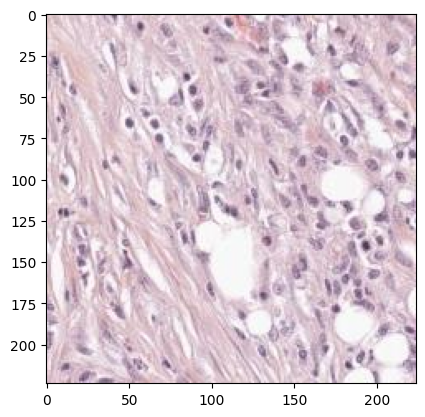

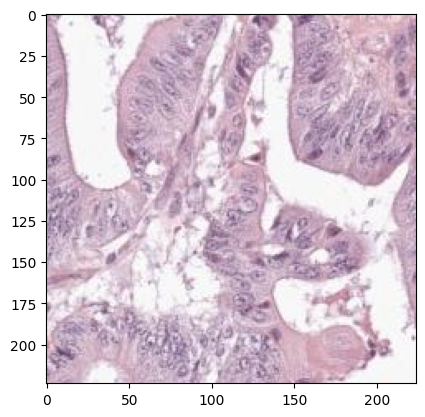

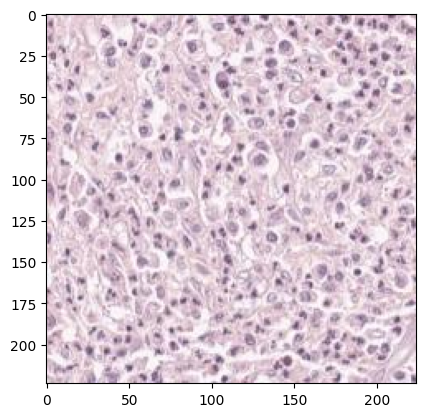

In [5]:
for img in dataset:
    plt.imshow(img)
    plt.show()

In [15]:
from torch.utils.data import DataLoader
import torchvision.transforms as v2

normalize = v2.Normalize(mean=[0.485, 0.456, 0.406],
                                 std=[0.229, 0.224, 0.225])

augmentation1 = [
        v2.RandomResizedCrop(224, scale=(0.2, 1.)),
        v2.RandomApply([
            v2.ColorJitter(0.4, 0.4, 0.2, 0.1)  # not strengthened
        ], p=0.8),
        v2.RandomGrayscale(p=0.2),
        v2.RandomApply([moco.loader.GaussianBlur([.1, 2.])], p=1.0),
        v2.RandomHorizontalFlip(),
        v2.ToTensor(),
        normalize
    ]

augmentation2 = [
    v2.RandomResizedCrop(224, scale=(0.2, 1.)),
    v2.RandomApply([
        v2.ColorJitter(0.4, 0.4, 0.2, 0.1)  # not strengthened
    ], p=0.8),
    v2.RandomGrayscale(p=0.2),
    v2.RandomApply([moco.loader.GaussianBlur([.1, 2.])], p=0.1),
    v2.RandomApply([moco.loader.Solarize()], p=0.2),
    v2.RandomHorizontalFlip(),
    normalize
]

collate_fn = MyCollateFunction()

# Num worker

train_loader = DataLoader(dataset, batch_size=2, shuffle=True, 
                        collate_fn = collate_fn, 
                        pin_memory=True,  drop_last=True,
                        #num_workers=1,
                       )

In [16]:
stain_augmentor = moco.stain_augmentation.all_free_version()
my_transform = CustomTransform(v2.Compose(augmentation1), 
                                                v2.Compose(augmentation2), 
                                                stain_augmentor)

torch.Size([2, 3, 224, 224])
Transforming images.
Staining time: 0.0188
torch.Size([3, 224, 224])
tensor(0.8628)
torch.Size([3, 224, 224])
tensor(0.7478)
Augmentation time: 0.0342


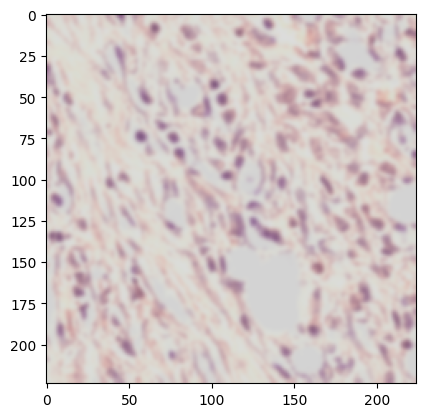

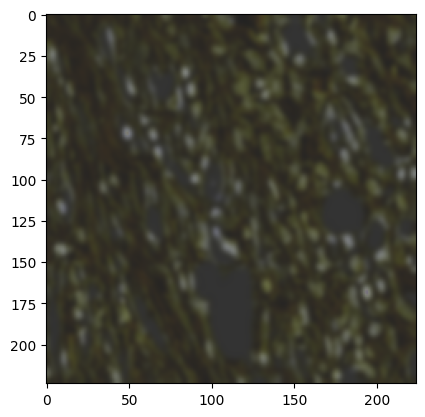

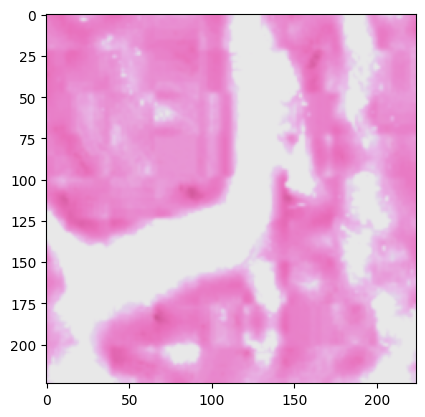

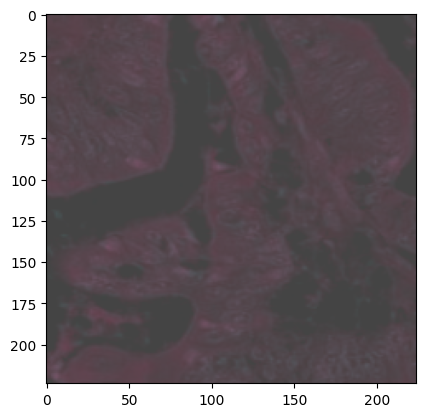

In [19]:
inv_normalize = v2.Normalize(
    mean=[-m/s for m, s in zip([0.485, 0.456, 0.406],
                               [0.229, 0.224, 0.225])],
    std=[1/s for s in [0.229, 0.224, 0.225]]
)
for i, batch in enumerate(train_loader):
    print(batch.shape)
    images = my_transform(batch)
    for i in range(len(images[0])):
        plt.imshow(inv_normalize(images[0][i].cpu()).permute(1, 2, 0))
        plt.show()
        plt.imshow(inv_normalize(images[1][i].cpu()).permute(1, 2, 0))
        plt.show()

In [ ]:
import os

os.path.join("test/test1", "*.tar")

# Test Virchow2

In [ ]:
from stamp.preprocessing.extractor.virchow2 import virchow2

In [ ]:
model = virchow2()

In [ ]:
model

In [ ]:
img = v2.ToTensor()(img)

In [ ]:
output = model.model(img.unsqueeze(0))

In [ ]:
repeat = torch.stack([img] * 50)
repeat.shape

In [ ]:
stain_matrix_mins: Tuple[float, float] = ((0.75, 0.80), (0.15, 0.2), (0.4, 0.6)),
stain_matrix_maxs: Tuple[float, float] = ((0.80, 1), (0.6, 0.7), (0.8, 0.9))
augmentor = StainAugmentor(od_mins=(0.5, 0.5), od_maxs=(2, 2), stain_matrix_mins=stain_matrix_mins,
                          stain_matrix_maxs=stain_matrix_maxs, color_system="hsv")
#augmentor = all_free_version()

In [ ]:
augmented = augmentor(repeat)

In [ ]:
augmented.shape

In [ ]:
aug_output = model.model(augmented)

In [ ]:
aug_output.shape

In [ ]:
all_out = torch.concatenate([output, aug_output]).detach().numpy()
all_out.shape

In [ ]:
from sklearn.decomposition import PCA

my_pca = PCA(2)
transformed = my_pca.fit_transform(all_out)

plt.scatter(transformed[0, 0], transformed[0, 1])
plt.scatter(transformed[1:, 0], transformed[1:, 1])

In [ ]:
from umap import UMAP

my_umap = UMAP(2)
transformed = my_umap.fit_transform(all_out)

plt.scatter(transformed[1:, 0], transformed[1:, 1])
plt.scatter(transformed[0, 0], transformed[0, 1])
plt.scatter(transformed[1:, 0].mean(), transformed[1:, 1].mean())

In [ ]:
from itertools import combinations
import torch.nn.functional as F

def mean_distance(embeddings, pairwise=True):
    if pairwise:
        pairs = list(combinations(range(len(embeddings)), 2))
    else:
        pairs = [(0, i) for i in range(1, len(embeddings))]
    distances = [
        1 - F.cosine_similarity(embeddings[i].unsqueeze(0), embeddings[j].unsqueeze(0))
        for i, j in pairs
    ]
    return torch.stack(distances).mean().item()

    

In [ ]:
print(mean_distance(torch.concatenate([output, aug_output])))
print(mean_distance(torch.concatenate([output, aug_output]), False))

In [ ]:
imgs = []
for im in dataset:
    imgs.append(im)
imgs = torch.stack(v2.ToTensor()(imgs))

mean_distance(imgs)

In [ ]:
48 + 9 + 7